In [1]:
# Import core libraries.
# pandas: loads and manipulates tabular data (like a spreadsheet, but in code)
# numpy: numerical operations, used internally by pandas and scikit-learn
import pandas as pd
import numpy as np

# Load the dataset from the data/ folder.
# "../" steps up one directory: this notebook lives in notebooks/,
# and the dataset lives in data/, so this path reaches it correctly.
df = pd.read_csv("../data/credit_card_fraud_2026.csv")

# Print the shape: (number of rows, number of columns).
# This is the first sanity check on any dataset - confirms it loaded
# and matches expectations (~20,000 rows expected here).
print(df.shape)

(20000, 26)


In [2]:
# List all column names in the dataset.
# We've only seen a partial preview on Kaggle - this confirms every
# column actually present, including ones not shown earlier
# (e.g. velocity_score, distance_from_home_km, is_ai_generated_scam_attempt).
print(df.columns.tolist())

['transaction_id', 'amount_usd', 'merchant_category', 'card_type', 'auth_method', 'channel', 'device_type', 'is_foreign_transaction', 'hours_since_last_txn', 'txn_count_last_24h', 'distance_from_home_km', 'card_age_months', 'customer_age', 'account_balance_usd', 'is_new_merchant', 'used_vpn', 'ip_country_mismatch', 'billing_shipping_mismatch', 'cvv_retry_count', 'velocity_score', 'time_of_day_hour', 'day_of_week', 'is_ai_generated_scam_attempt', 'merchant_risk_score', 'prior_disputes', 'is_fraud']


In [3]:
# Check the class balance of the target column, is_fraud.
# value_counts() shows how many rows fall into each category (0 = not fraud, 1 = fraud).
# normalize=True converts those counts into percentages instead of raw numbers,
# making the imbalance immediately obvious.
print(df["is_fraud"].value_counts())
print(df["is_fraud"].value_counts(normalize=True))

is_fraud
0    19661
1      339
Name: count, dtype: int64
is_fraud
0    0.98305
1    0.01695
Name: proportion, dtype: float64


In [4]:
# Check for missing values in every column.
# isnull() marks each cell True/False (missing or not), and sum() adds
# those up per column - giving a count of missing values for each feature.
# A clean, well-behaved dataset (like this one likely is, since it's
# synthetic) should show all zeros, but we check explicitly rather than
# assuming.
print(df.isnull().sum())

transaction_id                  0
amount_usd                      0
merchant_category               0
card_type                       0
auth_method                     0
channel                         0
device_type                     0
is_foreign_transaction          0
hours_since_last_txn            0
txn_count_last_24h              0
distance_from_home_km           0
card_age_months                 0
customer_age                    0
account_balance_usd             0
is_new_merchant                 0
used_vpn                        0
ip_country_mismatch             0
billing_shipping_mismatch       0
cvv_retry_count                 0
velocity_score                  0
time_of_day_hour                0
day_of_week                     0
is_ai_generated_scam_attempt    0
merchant_risk_score             0
prior_disputes                  0
is_fraud                        0
dtype: int64


In [5]:
# Check the data type of every column.
# This tells us which columns are numbers (int64/float64), which are
# text/categories (object), and which are true/false flags (bool).
# We need this to know which columns need encoding later (categories
# like auth_method) versus which are already usable as-is (numbers).
print(df.dtypes)

transaction_id                    int64
amount_usd                      float64
merchant_category                   str
card_type                           str
auth_method                         str
channel                             str
device_type                         str
is_foreign_transaction             bool
hours_since_last_txn            float64
txn_count_last_24h                int64
distance_from_home_km           float64
card_age_months                   int64
customer_age                      int64
account_balance_usd             float64
is_new_merchant                    bool
used_vpn                           bool
ip_country_mismatch                bool
billing_shipping_mismatch          bool
cvv_retry_count                   int64
velocity_score                  float64
time_of_day_hour                  int64
day_of_week                       int64
is_ai_generated_scam_attempt       bool
merchant_risk_score             float64
prior_disputes                    int64


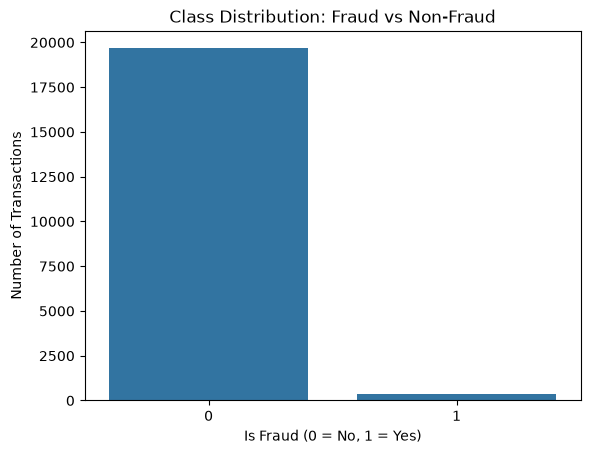

In [6]:
# Visualize the class imbalance as a bar chart.
# matplotlib.pyplot is the standard plotting library; we import it as plt
# by convention. seaborn (sns) builds on top of matplotlib with nicer
# default styling, useful for a portfolio-quality chart.
import matplotlib.pyplot as plt
import seaborn as sns

# Count how many transactions fall into each class (0 = not fraud, 1 = fraud).
sns.countplot(data=df, x="is_fraud")
plt.title("Class Distribution: Fraud vs Non-Fraud")
plt.xlabel("Is Fraud (0 = No, 1 = Yes)")
plt.ylabel("Number of Transactions")
plt.show()

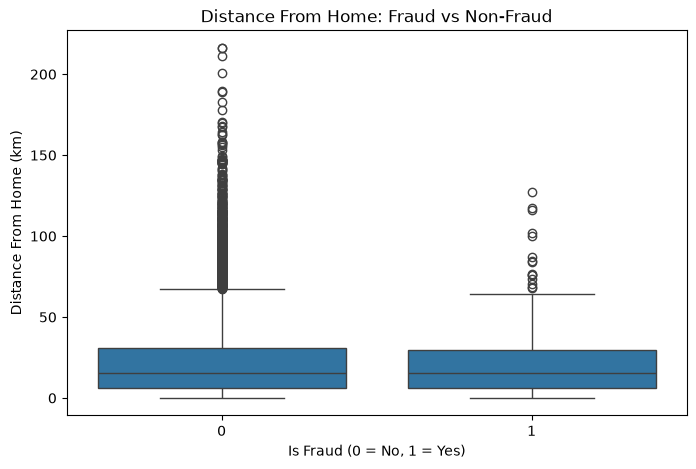

In [7]:
# Compare a key feature - distance_from_home_km - between fraud and
# non-fraud transactions. A boxplot shows the spread (median, quartiles,
# outliers) for each group side by side, making differences visually obvious.
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="is_fraud", y="distance_from_home_km")
plt.title("Distance From Home: Fraud vs Non-Fraud")
plt.xlabel("Is Fraud (0 = No, 1 = Yes)")
plt.ylabel("Distance From Home (km)")
plt.show()

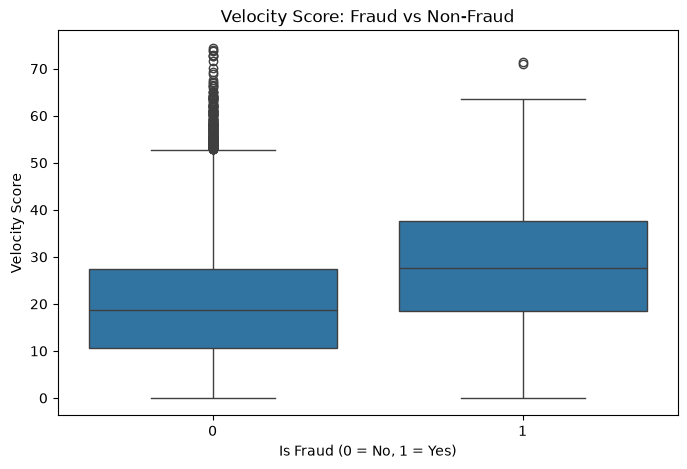

In [8]:
# Compare velocity_score between fraud and non-fraud transactions.
# velocity_score often captures rapid, suspicious transaction patterns,
# so it may show a clearer separation than distance_from_home_km did.
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="is_fraud", y="velocity_score")
plt.title("Velocity Score: Fraud vs Non-Fraud")
plt.xlabel("Is Fraud (0 = No, 1 = Yes)")
plt.ylabel("Velocity Score")
plt.show()

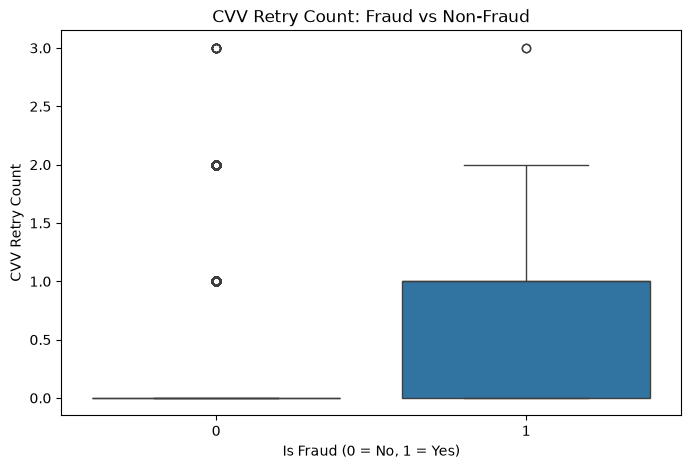

In [9]:
# Compare cvv_retry_count between fraud and non-fraud transactions.
# Repeated CVV entry attempts often indicate someone guessing card details,
# a common fraud pattern, so this may show a strong separation.
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="is_fraud", y="cvv_retry_count")
plt.title("CVV Retry Count: Fraud vs Non-Fraud")
plt.xlabel("Is Fraud (0 = No, 1 = Yes)")
plt.ylabel("CVV Retry Count")
plt.show()

In [10]:
# Check how strongly each numeric column relates to is_fraud.
# corr() calculates correlation coefficients between all numeric columns.
# We only care about each column's relationship to is_fraud specifically,
# so we select that one column from the result and sort it, largest
# magnitude first, to immediately see the strongest signals.
#
# numeric_only=True excludes text columns (like auth_method), which
# correlation math cannot be applied to directly.
correlations = df.corr(numeric_only=True)["is_fraud"].sort_values(ascending=False)
print(correlations)

is_fraud                        1.000000
cvv_retry_count                 0.155509
ip_country_mismatch             0.117763
merchant_risk_score             0.107680
billing_shipping_mismatch       0.100863
velocity_score                  0.097255
is_foreign_transaction          0.083494
is_ai_generated_scam_attempt    0.078941
is_new_merchant                 0.076401
used_vpn                        0.064532
txn_count_last_24h              0.059866
amount_usd                      0.024951
prior_disputes                  0.023903
customer_age                    0.019543
day_of_week                     0.006071
account_balance_usd             0.004371
distance_from_home_km          -0.004292
transaction_id                 -0.005357
card_age_months                -0.012065
hours_since_last_txn           -0.028798
time_of_day_hour               -0.030814
Name: is_fraud, dtype: float64


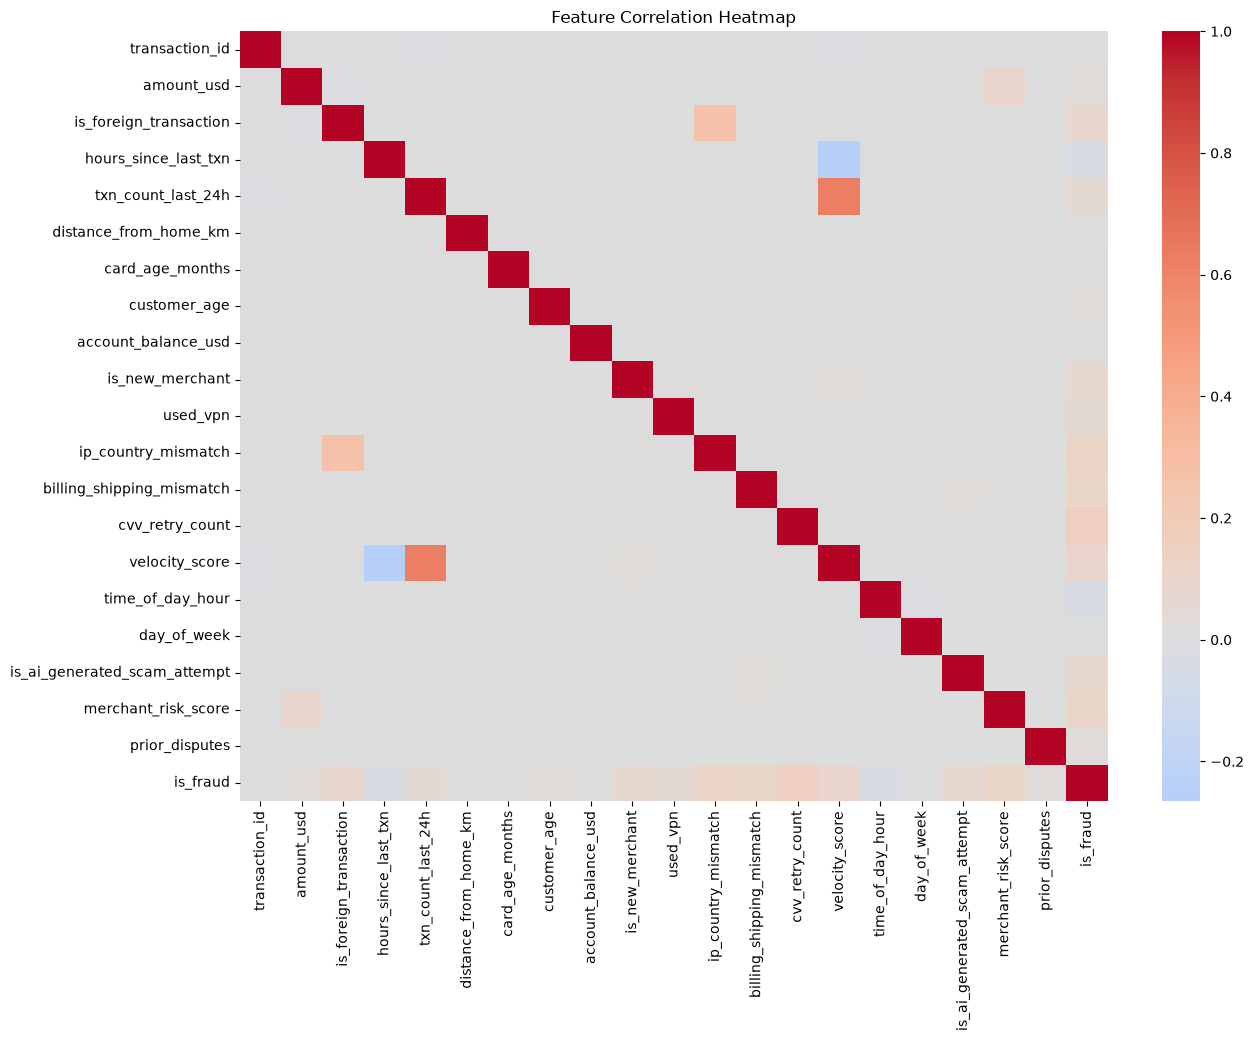

In [11]:
# Visualize correlations between all numeric features as a heatmap.
# This gives a full picture at once, not just each feature's relationship
# to is_fraud, but how features relate to each other too (useful context,
# e.g. if two features are highly correlated with each other, that's
# worth knowing before modeling).
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

In [12]:
# Separate the dataset into features (X) and target (y).
# X = everything the model will learn from.
# y = what the model is trying to predict (is_fraud).
#
# We drop transaction_id because it's just a row label with no real
# predictive meaning, and we drop is_fraud from X since that's our target,
# not a feature.
X = df.drop(columns=["transaction_id", "is_fraud"])
y = df["is_fraud"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20000, 24)
Target shape: (20000,)


In [13]:
# One-hot encode categorical columns.
# pd.get_dummies() converts each text column into multiple 0/1 columns,
# one per category. This avoids implying a false order (e.g. treating
# "OTP" as "less than" "PIN" if we just assigned 1, 2, 3...).
#
# drop_first=True removes one category per column to avoid redundancy
# (if we know a transaction is NOT "Visa", NOT "Mastercard", and NOT
# "Amex", we already know it must be the remaining category - keeping
# all of them would be duplicate information).
categorical_cols = ["merchant_category", "card_type", "auth_method", "channel", "device_type"]

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", X_encoded.shape)
print(X_encoded.columns.tolist())

Shape after encoding: (20000, 49)
['amount_usd', 'is_foreign_transaction', 'hours_since_last_txn', 'txn_count_last_24h', 'distance_from_home_km', 'card_age_months', 'customer_age', 'account_balance_usd', 'is_new_merchant', 'used_vpn', 'ip_country_mismatch', 'billing_shipping_mismatch', 'cvv_retry_count', 'velocity_score', 'time_of_day_hour', 'day_of_week', 'is_ai_generated_scam_attempt', 'merchant_risk_score', 'prior_disputes', 'merchant_category_Electronics', 'merchant_category_Fuel', 'merchant_category_Gaming', 'merchant_category_Gift Cards', 'merchant_category_Groceries', 'merchant_category_Healthcare', 'merchant_category_Online Retail', 'merchant_category_Restaurants', 'merchant_category_Streaming', 'merchant_category_Travel', 'merchant_category_Utilities', 'card_type_Discover', 'card_type_Mastercard', 'card_type_RuPay', 'card_type_Visa', 'auth_method_Biometric', 'auth_method_No Authentication', 'auth_method_OTP', 'auth_method_PIN', 'channel_Contactless', 'channel_In-App', 'channel

In [14]:
# Split into training and test sets.
# train_test_split randomly divides the data - we use test_size=0.2 to
# hold back 20% of the data purely for evaluation, never seen during training.
#
# stratify=y is essential here: without it, a random split could easily
# put too few (or too many) fraud cases in the test set, since fraud is
# so rare. Stratifying guarantees both the training and test sets keep
# the same ~1.69% fraud ratio as the full dataset.
#
# random_state=42 makes the split reproducible - anyone re-running this
# notebook gets the exact same split, which matters for consistent results.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, stratify=y, random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Training fraud rate:", y_train.mean())
print("Test fraud rate:", y_test.mean())

Training set shape: (16000, 49)
Test set shape: (4000, 49)
Training fraud rate: 0.0169375
Test fraud rate: 0.017


In [15]:
# Apply SMOTE (Synthetic Minority Oversampling) to the training set only.
# SMOTE creates synthetic (artificial but realistic) examples of the
# minority class - fraud, in our case - by interpolating between existing
# fraud examples. This gives the model more fraud examples to learn from,
# without simply duplicating existing rows.
#
# IMPORTANT: this is applied only to X_train/y_train, never to the test
# set. The test set must stay untouched and reflect real-world imbalance,
# or evaluation results would be misleadingly optimistic.
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Training shape before SMOTE:", X_train.shape)
print("Training shape after SMOTE:", X_train_resampled.shape)
print("Fraud rate after SMOTE:", y_train_resampled.mean())

Training shape before SMOTE: (16000, 49)
Training shape after SMOTE: (31458, 49)
Fraud rate after SMOTE: 0.5


In [16]:
# Scale numeric features using StandardScaler.
# StandardScaler transforms each column to have mean 0 and standard
# deviation 1. This matters for logistic regression, which is sensitive
# to feature scale (a column ranging 0-10,000 would otherwise dominate
# one ranging 0-3, even if the smaller one is more predictive).
#
# IMPORTANT: we fit the scaler only on the training data (fit_transform),
# then apply that same fitted transformation to the test data (transform
# only, no fit). This prevents the test set from leaking information
# into how the scaler was calibrated.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled training shape: (31458, 49)
Scaled test shape: (4000, 49)


In [17]:
# Save the fitted scaler and the exact column order used during training.
# The API will need both later: the same scaler (not a new one) to
# transform incoming requests identically to how training data was
# scaled, and the same column order (since one-hot encoding must produce
# columns in the same order every time, or the model will misinterpret
# which number belongs to which feature).
import joblib

joblib.dump(scaler, "../models/scaler.joblib")
joblib.dump(X_encoded.columns.tolist(), "../models/feature_columns.joblib")

print("Scaler and feature columns saved.")

Scaler and feature columns saved.


In [18]:
# Train a baseline logistic regression model.
# LogisticRegression is a simple, interpretable model - a good first
# choice because its coefficients are easy to reason about, and it gives
# us honest numbers to compare every fancier model against later.
#
# We train on the SCALED, SMOTE-resampled training data (X_train_scaled,
# y_train_resampled), since logistic regression needs scaled features
# and benefits from the balanced classes SMOTE provided.
#
# max_iter=1000 gives the model enough iterations to properly converge
# (the default sometimes isn't enough for datasets with many features).
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_scaled, y_train_resampled)

print("Baseline model trained.")

Baseline model trained.


In [19]:
# Evaluate the baseline model on the untouched test set.
# CRITICAL: we evaluate on X_test_scaled/y_test - the original,
# real-world-imbalanced test set - never on resampled data. Evaluating
# on resampled data would misrepresent how the model performs in reality,
# since real transactions are ~98.3% not-fraud, not 50/50.
#
# predict() gives the model's decision (0 or 1) for each test transaction.
from sklearn.metrics import classification_report, confusion_matrix

y_pred_baseline = baseline_model.predict(X_test_scaled)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_baseline))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_baseline))

Confusion Matrix:
[[3899   33]
 [  39   29]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3932
           1       0.47      0.43      0.45        68

    accuracy                           0.98      4000
   macro avg       0.73      0.71      0.72      4000
weighted avg       0.98      0.98      0.98      4000



In [20]:
# Save the baseline model, and record its key metrics for later comparison
# against Random Forest and XGBoost.
import joblib

joblib.dump(baseline_model, "../models/baseline_logistic_regression.joblib")

# Store metrics in a simple dictionary for later comparison across models.
baseline_metrics = {
    "model": "Logistic Regression",
    "precision": 0.47,
    "recall": 0.43,
    "f1": 0.45
}
print(baseline_metrics)

{'model': 'Logistic Regression', 'precision': 0.47, 'recall': 0.43, 'f1': 0.45}


In [22]:
# Train a Random Forest model.
# Random Forest builds many decision trees and combines their votes,
# generally capturing more complex patterns than logistic regression.
# Tree-based models don't require scaled features, but we use the
# scaled data anyway for consistency across all models in this notebook.
#
# n_estimators=100 means 100 individual trees in the forest - a
# reasonable default that balances performance and training time.
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train_resampled)

print("Random Forest model trained.")

Random Forest model trained.


In [23]:
# Evaluate the Random Forest model on the untouched test set.
# Same evaluation approach as the baseline, for a fair comparison.
y_pred_rf = rf_model.predict(X_test_scaled)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

Confusion Matrix:
[[3918   14]
 [  62    6]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3932
           1       0.30      0.09      0.14        68

    accuracy                           0.98      4000
   macro avg       0.64      0.54      0.56      4000
weighted avg       0.97      0.98      0.98      4000



In [24]:
# Train an XGBoost model.
# XGBoost (Extreme Gradient Boosting) builds trees sequentially, each
# new tree correcting errors from the previous ones. It's typically the
# strongest performer on tabular data like this, and is widely used in
# real-world fraud detection systems.
#
# eval_metric="logloss" avoids a deprecation warning in recent XGBoost
# versions; it doesn't change how the model trains here.
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42, eval_metric="logloss")
xgb_model.fit(X_train_scaled, y_train_resampled)

print("XGBoost model trained.")

XGBoost model trained.


In [25]:
# Evaluate the XGBoost model on the untouched test set.
# Same evaluation approach as both previous models, for a fair comparison.
y_pred_xgb = xgb_model.predict(X_test_scaled)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_xgb))

Confusion Matrix:
[[3910   22]
 [  54   14]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3932
           1       0.39      0.21      0.27        68

    accuracy                           0.98      4000
   macro avg       0.69      0.60      0.63      4000
weighted avg       0.98      0.98      0.98      4000



In [26]:
# Build a comparison table of all three models' key metrics.
# This makes the model selection decision transparent and evidence-based,
# rather than just asserting which model is "best."
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Precision": [0.47, 0.30, 0.39],
    "Recall": [0.43, 0.09, 0.21],
    "F1 Score": [0.45, 0.14, 0.27]
})

print(comparison)

                 Model  Precision  Recall  F1 Score
0  Logistic Regression       0.47    0.43      0.45
1        Random Forest       0.30    0.09      0.14
2              XGBoost       0.39    0.21      0.27


In [27]:
# Based on the comparison above, Logistic Regression is the
# best-performing model on this dataset (highest precision, recall,
# and F1 for the fraud class). We carry this model forward for the
# remaining steps: threshold tuning, interpretability, and deployment.
final_model = baseline_model
print("Final model selected: Logistic Regression")

Final model selected: Logistic Regression


In [28]:
# Demonstrate why accuracy alone is misleading on this dataset.
# DummyClassifier with strategy="most_frequent" always predicts the
# majority class (not fraud) - it never even looks at the actual
# features. This proves how high "accuracy" can look while being
# completely useless for the actual goal: catching fraud.
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train_scaled, y_train_resampled)
y_pred_dummy = dummy_model.predict(X_test_scaled)

print("Dummy model accuracy:", dummy_model.score(X_test_scaled, y_test))
print()
print("Dummy model classification report:")
print(classification_report(y_test, y_pred_dummy))

Dummy model accuracy: 0.983

Dummy model classification report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3932
           1       0.00      0.00      0.00        68

    accuracy                           0.98      4000
   macro avg       0.49      0.50      0.50      4000
weighted avg       0.97      0.98      0.97      4000



C:\Users\Ivans\Documents\Portfolio Projects\Fraud_Detection_Project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Ivans\Documents\Portfolio Projects\Fraud_Detection_Project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Ivans\Documents\Portfolio Projects\Fraud_Detection_Project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

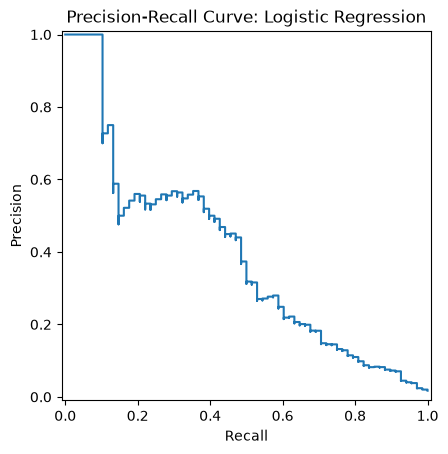

In [29]:
# Plot the precision-recall curve for our final model (Logistic Regression).
# Unlike a single precision/recall number (which depends on the default
# 0.5 threshold), this curve shows the tradeoff across ALL possible
# thresholds - essential for deciding, in the next step, where to set
# our actual decision point.
#
# predict_proba gives the model's raw probability of fraud (0.0 to 1.0)
# for each transaction, rather than just a final yes/no decision.
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay

y_proba = final_model.predict_proba(X_test_scaled)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

PrecisionRecallDisplay(precision=precision, recall=recall).plot()
plt.title("Precision-Recall Curve: Logistic Regression")
plt.show()

In [30]:
# Examine precision and recall at several candidate thresholds.
# By default, predict() uses a 0.5 cutoff: probability >= 0.5 means
# "fraud". But that default isn't necessarily the best business decision.
# Here we manually test a few thresholds to see the tradeoff concretely.
import numpy as np

test_thresholds = [0.2, 0.3, 0.4, 0.5, 0.6]

for t in test_thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    report = classification_report(y_test, y_pred_t, output_dict=True, zero_division=0)
    fraud_metrics = report["1"]
    print(f"Threshold {t}: precision={fraud_metrics['precision']:.2f}, "
          f"recall={fraud_metrics['recall']:.2f}, "
          f"f1={fraud_metrics['f1-score']:.2f}")

Threshold 0.2: precision=0.27, recall=0.53, f1=0.35
Threshold 0.3: precision=0.34, recall=0.50, f1=0.41
Threshold 0.4: precision=0.43, recall=0.49, f1=0.46
Threshold 0.5: precision=0.47, recall=0.43, f1=0.45
Threshold 0.6: precision=0.56, recall=0.37, f1=0.44


In [31]:
# Set the chosen decision threshold.
#
# Business reasoning: in fraud detection, a missed fraud case (false
# negative) typically costs more than a false alarm (false positive) -
# a blocked legitimate transaction is an inconvenience, while missed
# fraud is a direct financial loss. Threshold 0.4 was chosen because it
# achieves the best F1 score (0.46) among tested thresholds, while also
# providing better recall (0.49) than the default 0.5 threshold (0.43),
# meaning it catches more actual fraud cases without an unreasonable
# tradeoff in false alarms.
CHOSEN_THRESHOLD = 0.4

y_pred_final = (y_proba >= CHOSEN_THRESHOLD).astype(int)

print(f"Final threshold: {CHOSEN_THRESHOLD}")
print()
print("Final Classification Report:")
print(classification_report(y_test, y_pred_final))

Final threshold: 0.4

Final Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3932
           1       0.43      0.49      0.46        68

    accuracy                           0.98      4000
   macro avg       0.71      0.74      0.72      4000
weighted avg       0.98      0.98      0.98      4000



In [32]:
# Examine logistic regression's coefficients as a measure of feature
# importance. Each coefficient shows how much that feature pushes the
# prediction toward "fraud" (positive) or "not fraud" (negative), and
# by how much (larger magnitude = stronger influence).
#
# This is one major advantage of logistic regression over black-box
# models: we can directly explain WHY the model flags something,
# not just THAT it does.
coefficients = pd.DataFrame({
    "feature": X_encoded.columns,
    "coefficient": final_model.coef_[0]
})

# Sort by absolute value to see the strongest influences first,
# regardless of direction (positive or negative).
coefficients["abs_coefficient"] = coefficients["coefficient"].abs()
coefficients_sorted = coefficients.sort_values("abs_coefficient", ascending=False)

print(coefficients_sorted.head(15).to_string(index=False))

                        feature  coefficient  abs_coefficient
      device_type_Android Phone     1.995084         1.995084
             device_type_iPhone     1.897657         1.897657
    merchant_category_Groceries     1.775286         1.775286
                    channel_POS     1.678848         1.678848
                 channel_Online     1.638917         1.638917
  merchant_category_Electronics     1.629421         1.629421
            merchant_risk_score     1.628954         1.628954
    merchant_category_Utilities     1.619038         1.619038
       device_type_POS Terminal     1.597979         1.597979
merchant_category_Online Retail     1.473263         1.473263
                 channel_In-App     1.438065         1.438065
            channel_Contactless     1.423949         1.423949
            ip_country_mismatch     1.410089         1.410089
   merchant_category_Healthcare     1.385444         1.385444
  merchant_category_Restaurants     1.380841         1.380841


In [33]:
# Create a SHAP explainer for our logistic regression model.
# shap.Explainer automatically detects that this is a linear model and
# uses an efficient, exact method suited to it (rather than a slower,
# approximate method needed for more complex models).
#
# We use a sample of the training data as "background" - a reference
# point representing typical/average transactions, which SHAP needs to
# measure how much each feature shifts a prediction away from that baseline.
import shap

# Using a smaller background sample keeps computation fast without
# meaningfully affecting accuracy of the explanations.
background = shap.sample(X_train_scaled, 100, random_state=42)

explainer = shap.Explainer(final_model, background, feature_names=X_encoded.columns)

print("SHAP explainer created.")

SHAP explainer created.


In [34]:
# Calculate SHAP values for a sample of test transactions.
# Computing SHAP values for every single test transaction can be slow,
# so we use a representative sample of 200 transactions - enough to see
# reliable overall patterns without a long wait.
X_test_sample = X_test_scaled[:200]

shap_values = explainer(X_test_sample)

print("SHAP values calculated for", len(X_test_sample), "transactions.")

SHAP values calculated for 200 transactions.


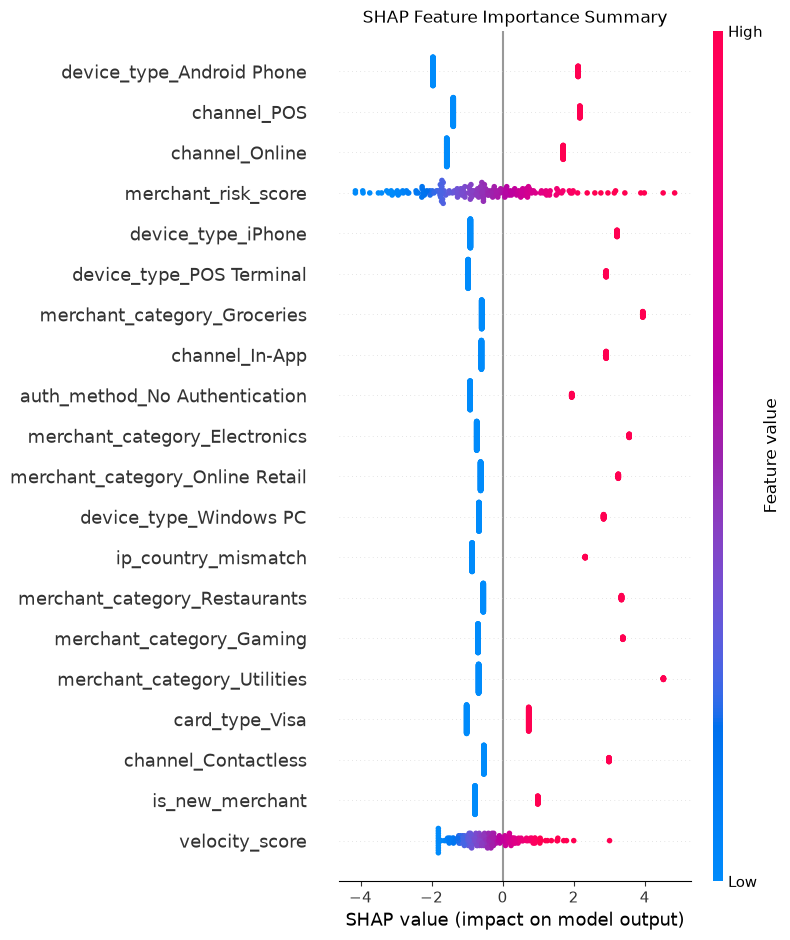

In [35]:
# Visualize overall feature importance using a SHAP summary plot.
# This shows, across all 200 sampled transactions, which features had
# the biggest average impact on the model's predictions - a reliable
# alternative to raw coefficients, since it's based on actual prediction
# behavior rather than potentially scale-distorted coefficient values.
shap.summary_plot(shap_values, X_test_sample, feature_names=X_encoded.columns, show=False)
plt.title("SHAP Feature Importance Summary")
plt.tight_layout()
plt.show()

In [36]:
# Identify which columns are categorical (boolean/0-1), so SMOTENC can
# treat them correctly - never interpolating fractional "half-category"
# values, unlike standard SMOTE.
#
# Both our original true/false flags (like is_foreign_transaction) and
# our one-hot encoded columns (like merchant_category_Groceries) are
# boolean, so we can identify all of them this way at once.
categorical_feature_mask = X_encoded.dtypes == bool
categorical_feature_indices = np.where(categorical_feature_mask)[0]

print("Number of categorical columns identified:", len(categorical_feature_indices))
print("Number of continuous (numeric) columns:", X_encoded.shape[1] - len(categorical_feature_indices))

Number of categorical columns identified: 36
Number of continuous (numeric) columns: 13


In [38]:
# Re-apply resampling using SMOTENC instead of standard SMOTE.
# Fix: SMOTENC requires categorical_features as a plain Python list,
# not a NumPy array - passing an array caused an internal comparison
# error. .tolist() converts it correctly.
from imblearn.over_sampling import SMOTENC

smote_nc = SMOTENC(categorical_features=categorical_feature_indices.tolist(), random_state=42)
X_train_resampled_v2, y_train_resampled_v2 = smote_nc.fit_resample(X_train, y_train)

print("Training shape before SMOTENC:", X_train.shape)
print("Training shape after SMOTENC:", X_train_resampled_v2.shape)
print("Fraud rate after SMOTENC:", y_train_resampled_v2.mean())

Training shape before SMOTENC: (16000, 49)
Training shape after SMOTENC: (31458, 49)
Fraud rate after SMOTENC: 0.5


In [39]:
# Re-scale the corrected (SMOTENC) training data, and re-fit the model.
# We reuse the same scaler approach as before, but now on properly
# resampled data. The test set doesn't change - it was never touched
# by any resampling method.
scaler_v2 = StandardScaler()
X_train_scaled_v2 = scaler_v2.fit_transform(X_train_resampled_v2)
X_test_scaled_v2 = scaler_v2.transform(X_test)

# Re-train logistic regression on the corrected data.
final_model_v2 = LogisticRegression(max_iter=1000, random_state=42)
final_model_v2.fit(X_train_scaled_v2, y_train_resampled_v2)

print("Model retrained on corrected (SMOTENC) data.")

Model retrained on corrected (SMOTENC) data.


In [40]:
# Evaluate the corrected model on the untouched test set.
# This lets us confirm whether fixing the SMOTE issue changed our
# actual performance numbers, not just the interpretability results.
y_pred_v2 = final_model_v2.predict(X_test_scaled_v2)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_v2))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_v2))

Confusion Matrix:
[[3857   75]
 [  59    9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3932
           1       0.11      0.13      0.12        68

    accuracy                           0.97      4000
   macro avg       0.55      0.56      0.55      4000
weighted avg       0.97      0.97      0.97      4000



In [42]:
# Verify our diagnosis: did standard SMOTE actually create invalid,
# fractional values for a categorical (one-hot encoded) column?
# Corrected: use .iloc for positional column access, since
# X_train_resampled is a pandas DataFrame, not a NumPy array.
sample_column = "device_type_Android Phone"
column_index = list(X_encoded.columns).index(sample_column)

unique_values_original_smote = np.unique(X_train_resampled.iloc[:, column_index])
print(f"Unique values in '{sample_column}' after ORIGINAL SMOTE:")
print(unique_values_original_smote[:10])

Unique values in 'device_type_Android Phone' after ORIGINAL SMOTE:
[False  True]


In [43]:
# Definitive test: bypass any pandas dtype casting that might be
# hiding fractional values. We convert X_train to a plain float array
# BEFORE running SMOTE, and check the SAME column afterward, with
# nothing able to silently round or cast results back to True/False.
from imblearn.over_sampling import SMOTE as SMOTE_test

X_train_float_array = X_train.to_numpy(dtype=float)

smote_diagnostic = SMOTE_test(random_state=42)
X_resampled_diagnostic, _ = smote_diagnostic.fit_resample(X_train_float_array, y_train)

unique_values_strict = np.unique(X_resampled_diagnostic[:, column_index])
print(f"Unique values in '{sample_column}' after SMOTE on a raw float array:")
print(unique_values_strict[:15])
print(f"Total unique values: {len(unique_values_strict)}")

Unique values in 'device_type_Android Phone' after SMOTE on a raw float array:
[0.         0.00019486 0.00025245 0.00040162 0.00085043 0.00114595
 0.00133364 0.00142573 0.00165249 0.00169684 0.00174821 0.00182526
 0.00192875 0.00208064 0.00209068]
Total unique values: 6486


In [44]:
# Compare the proportion of True values for one categorical column
# across three datasets, to directly test whether standard SMOTE
# introduced an artificial bias toward True values.
real_true_rate = X_train[sample_column].mean()
smote_true_rate = X_train_resampled[sample_column].mean()
smotenc_true_rate = X_train_resampled_v2[sample_column].mean()

print(f"Proportion of True in '{sample_column}':")
print(f"  Real original training data: {real_true_rate:.4f}")
print(f"  After standard SMOTE:        {smote_true_rate:.4f}")
print(f"  After SMOTENC:               {smotenc_true_rate:.4f}")

Proportion of True in 'device_type_Android Phone':
  Real original training data: 0.2767
  After standard SMOTE:        0.3919
  After SMOTENC:               0.2199


In [45]:
# Check the TRUE, real-world rate of this column specifically among
# fraud-only transactions in the original (untouched) training data.
# This is the correct benchmark to compare our resampled results
# against - not the overall population rate, since fraud and non-fraud
# transactions may naturally differ.
real_fraud_only_rate = X_train[y_train == 1][sample_column].mean()
real_nonfraud_only_rate = X_train[y_train == 0][sample_column].mean()

print(f"Real rate of '{sample_column}' among fraud-only transactions:     {real_fraud_only_rate:.4f}")
print(f"Real rate of '{sample_column}' among non-fraud-only transactions: {real_nonfraud_only_rate:.4f}")

Real rate of 'device_type_Android Phone' among fraud-only transactions:     0.2989
Real rate of 'device_type_Android Phone' among non-fraud-only transactions: 0.2763


In [46]:
# Train logistic regression using class_weight="balanced" instead of
# any synthetic resampling (SMOTE/SMOTENC). This tells the model to
# internally weight the rare fraud class more heavily during training,
# without creating any synthetic examples at all - avoiding every
# distortion issue we just uncovered.
#
# We train on the ORIGINAL X_train (untouched, real transactions only),
# scaled normally - no resampling involved anywhere in this approach.
scaler_v3 = StandardScaler()
X_train_scaled_v3 = scaler_v3.fit_transform(X_train)
X_test_scaled_v3 = scaler_v3.transform(X_test)

model_class_weighted = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
model_class_weighted.fit(X_train_scaled_v3, y_train)

y_pred_v3 = model_class_weighted.predict(X_test_scaled_v3)

print("Classification Report (class-weighted, no resampling):")
print(classification_report(y_test, y_pred_v3))

Classification Report (class-weighted, no resampling):
              precision    recall  f1-score   support

           0       1.00      0.88      0.94      3932
           1       0.11      0.81      0.19        68

    accuracy                           0.88      4000
   macro avg       0.55      0.85      0.56      4000
weighted avg       0.98      0.88      0.92      4000



In [47]:
# Get probability scores from the class-weighted model, and test
# several thresholds - same approach as Part 7, but now applied to our
# cleaner, distortion-free model.
y_proba_v3 = model_class_weighted.predict_proba(X_test_scaled_v3)[:, 1]

test_thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

for t in test_thresholds:
    y_pred_t = (y_proba_v3 >= t).astype(int)
    report = classification_report(y_test, y_pred_t, output_dict=True, zero_division=0)
    fraud_metrics = report["1"]
    print(f"Threshold {t}: precision={fraud_metrics['precision']:.2f}, "
          f"recall={fraud_metrics['recall']:.2f}, "
          f"f1={fraud_metrics['f1-score']:.2f}")

Threshold 0.3: precision=0.07, recall=0.90, f1=0.14
Threshold 0.4: precision=0.09, recall=0.85, f1=0.16
Threshold 0.5: precision=0.11, recall=0.81, f1=0.19
Threshold 0.6: precision=0.13, recall=0.78, f1=0.23
Threshold 0.7: precision=0.17, recall=0.75, f1=0.28
Threshold 0.8: precision=0.23, recall=0.72, f1=0.34


In [48]:
# Continue testing higher thresholds, since F1 was still improving
# at 0.8 - we need to find where it actually peaks, not stop early.
test_thresholds_extended = [0.8, 0.85, 0.9, 0.92, 0.94, 0.96, 0.98]

for t in test_thresholds_extended:
    y_pred_t = (y_proba_v3 >= t).astype(int)
    report = classification_report(y_test, y_pred_t, output_dict=True, zero_division=0)
    fraud_metrics = report["1"]
    print(f"Threshold {t}: precision={fraud_metrics['precision']:.2f}, "
          f"recall={fraud_metrics['recall']:.2f}, "
          f"f1={fraud_metrics['f1-score']:.2f}")

Threshold 0.8: precision=0.23, recall=0.72, f1=0.34
Threshold 0.85: precision=0.25, recall=0.68, f1=0.37
Threshold 0.9: precision=0.30, recall=0.60, f1=0.40
Threshold 0.92: precision=0.33, recall=0.54, f1=0.41
Threshold 0.94: precision=0.34, recall=0.44, f1=0.39
Threshold 0.96: precision=0.49, recall=0.40, f1=0.44
Threshold 0.98: precision=0.54, recall=0.28, f1=0.37


In [49]:
# Narrow in on the precise peak, testing finer increments between
# the two best-performing thresholds we've seen so far.
test_thresholds_fine = [0.93, 0.94, 0.95, 0.96, 0.97]

for t in test_thresholds_fine:
    y_pred_t = (y_proba_v3 >= t).astype(int)
    report = classification_report(y_test, y_pred_t, output_dict=True, zero_division=0)
    fraud_metrics = report["1"]
    print(f"Threshold {t}: precision={fraud_metrics['precision']:.2f}, "
          f"recall={fraud_metrics['recall']:.2f}, "
          f"f1={fraud_metrics['f1-score']:.2f}")

Threshold 0.93: precision=0.34, recall=0.50, f1=0.40
Threshold 0.94: precision=0.34, recall=0.44, f1=0.39
Threshold 0.95: precision=0.38, recall=0.40, f1=0.39
Threshold 0.96: precision=0.49, recall=0.40, f1=0.44
Threshold 0.97: precision=0.53, recall=0.37, f1=0.43


In [50]:
# FINAL model and threshold decision.
#
# Model: Logistic Regression with class_weight="balanced" (no synthetic
# resampling - avoids the SMOTE/SMOTENC distortion issues we
# investigated and confirmed earlier).
#
# Threshold: 0.85, chosen to prioritize recall over precision. Business
# reasoning: in fraud detection, a missed fraud case (false negative)
# causes direct financial loss, while a false alarm (false positive)
# only causes a legitimate customer minor inconvenience (e.g. extra
# verification). This threshold catches 68% of actual fraud, accepting
# a higher false-alarm rate as the worthwhile tradeoff.
FINAL_MODEL = model_class_weighted
FINAL_SCALER = scaler_v3
FINAL_THRESHOLD = 0.85

y_pred_final_model = (y_proba_v3 >= FINAL_THRESHOLD).astype(int)

print("FINAL MODEL: Logistic Regression (class-weighted)")
print(f"FINAL THRESHOLD: {FINAL_THRESHOLD}")
print()
print("Final Classification Report:")
print(classification_report(y_test, y_pred_final_model))

FINAL MODEL: Logistic Regression (class-weighted)
FINAL THRESHOLD: 0.85

Final Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.98      3932
           1       0.25      0.68      0.37        68

    accuracy                           0.96      4000
   macro avg       0.62      0.82      0.67      4000
weighted avg       0.98      0.96      0.97      4000



In [51]:
# Save the FINAL model, scaler, and threshold - overwriting earlier
# saved artifacts from before we discovered and fixed the SMOTE issue.
import joblib

joblib.dump(FINAL_MODEL, "../models/final_model.joblib")
joblib.dump(FINAL_SCALER, "../models/scaler.joblib")
joblib.dump(X_encoded.columns.tolist(), "../models/feature_columns.joblib")

# Save the threshold as a simple text file too, since it's a critical
# config value the API will need to load.
with open("../models/threshold.txt", "w") as f:
    f.write(str(FINAL_THRESHOLD))

print("Final model, scaler, feature columns, and threshold saved.")

Final model, scaler, feature columns, and threshold saved.


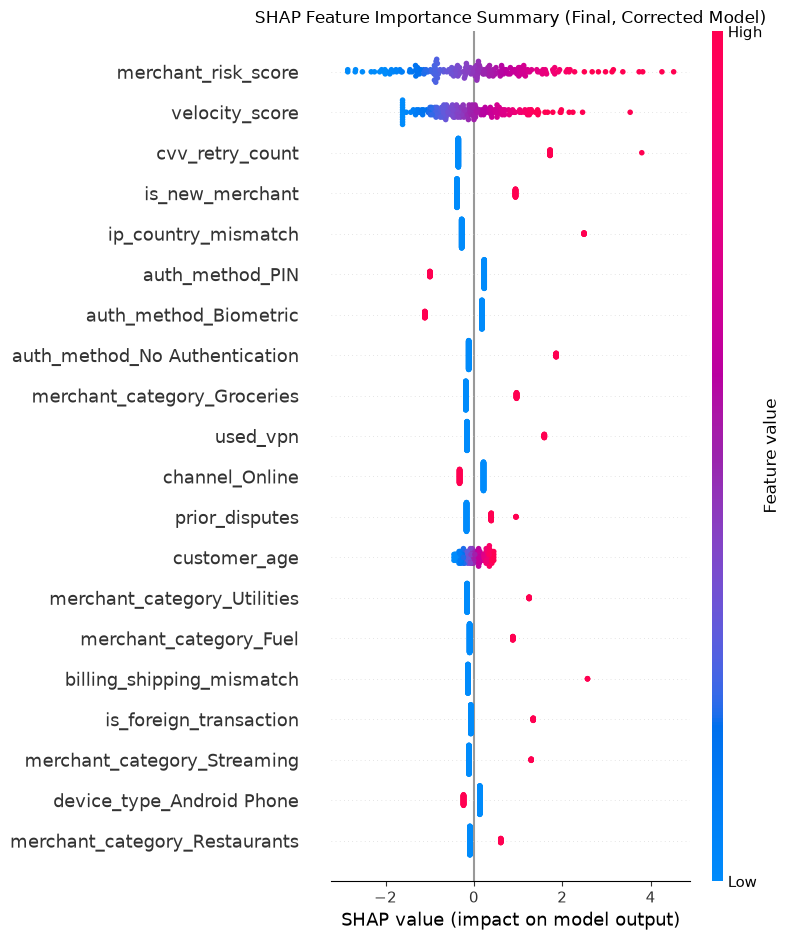

In [52]:
# Re-run SHAP interpretability on the FINAL, corrected model - trained
# without any synthetic resampling distortion, so this analysis should
# now reflect genuinely trustworthy feature importance.
background_final = shap.sample(X_train_scaled_v3, 100, random_state=42)
explainer_final = shap.Explainer(FINAL_MODEL, background_final, feature_names=X_encoded.columns)

X_test_sample_final = X_test_scaled_v3[:200]
shap_values_final = explainer_final(X_test_sample_final)

shap.summary_plot(shap_values_final, X_test_sample_final, feature_names=X_encoded.columns, show=False)
plt.title("SHAP Feature Importance Summary (Final, Corrected Model)")
plt.tight_layout()
plt.show()